In [1]:
# import libraries

import pandas as pd
import seaborn as sns
import numpy as np

from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

from collections import defaultdict

from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
import matplotlib.path as mpath
from matplotlib.colors import PowerNorm, LinearSegmentedColormap
import matplotlib.patheffects as path_effects

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# read in testing data

data = pd.read_csv('../../local_data/TestDataPredictionsRF.csv')
print(data.columns)

# read in training data

training_data = pd.read_csv('../../local_data/training_asset_sample.csv')
print(training_data.columns)

# seaborn things

sns.set_context('paper')
BG_COLOR = '#ffffff'

sns.set_theme(style="white", font_scale=1.2)
plt.rcParams['figure.facecolor'] = BG_COLOR
plt.rcParams['axes.facecolor'] = BG_COLOR
plt.rcParams['savefig.facecolor'] = BG_COLOR

# unpack probabilites into separate columns

probs = data['probabilities'].str.strip('[]').str.split(', ', expand=True).astype(float)
probs.columns = [f'prob_class_{i + 1}' for i in range(probs.shape[1])]
data = pd.concat([data, probs], axis=1)
print(f"\nProbabilities unpacked into separate columns: {probs.columns.tolist()}")

# and format data (for testing separate by sensor)

y_true = data["class_id"]
y_pred = data["classification"]

Index(['system:index', 'blue', 'class_id', 'classification', 'fold_rand',
       'green', 'nir', 'probabilities', 'red', 'sensor', 'swir1', 'swir2',
       '.geo'],
      dtype='object')
Index(['class', 'class_id', 'blue', 'green', 'red', 'nir', 'swir1', 'swir2',
       '.geo', 'sensor'],
      dtype='object')

Probabilities unpacked into separate columns: ['prob_class_1', 'prob_class_2', 'prob_class_3', 'prob_class_4']


**Reliability Diagrams**

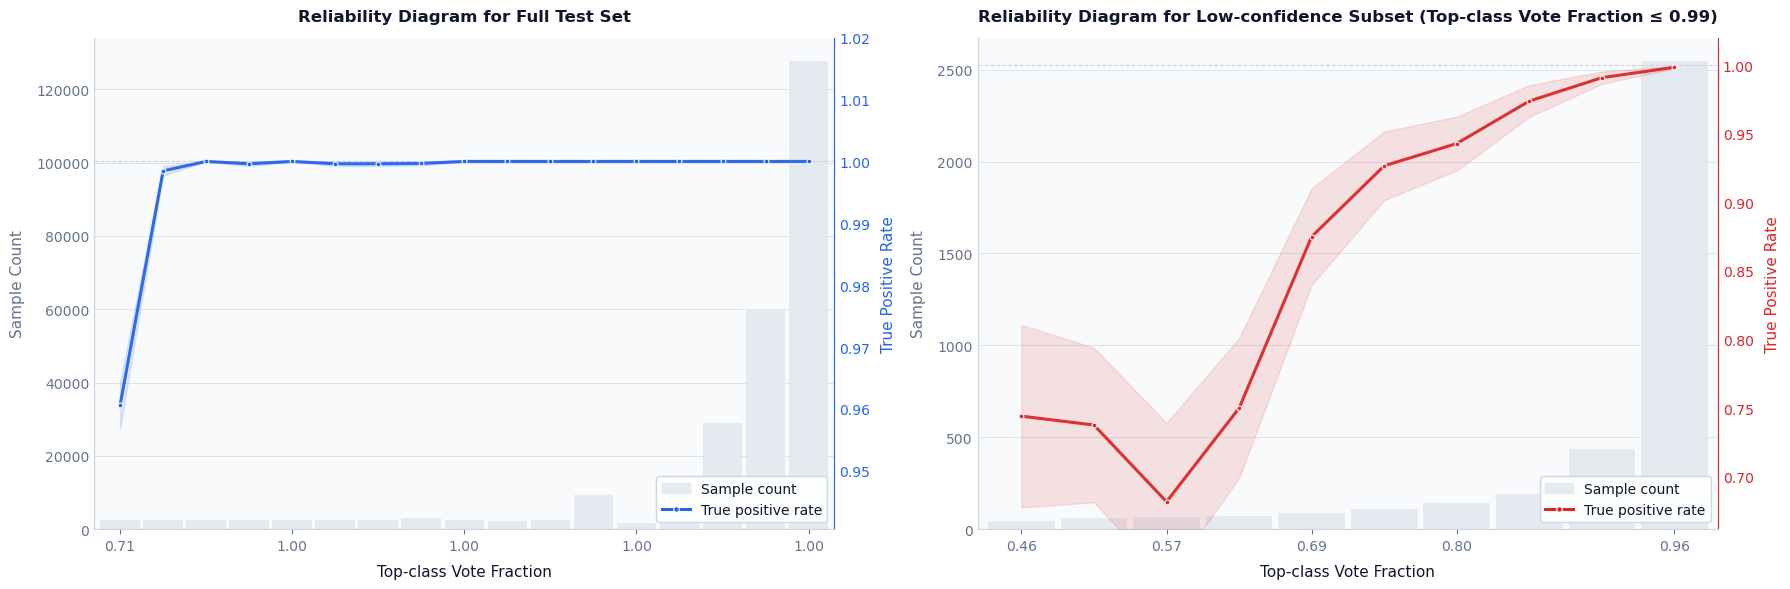

In [137]:
# data prep

data['correctness_class'] = np.where(
    data['class_id'] == data['classification'], 'True Positive', 'False Positive'
)

prob_cols    = [col for col in data.columns if 'prob_class' in col]
probs_array  = data[prob_cols].values
sorted_probs = np.sort(probs_array, axis=1)
data['top_prob'] = sorted_probs[:, -1]

# helper to cut bins using pd.cut and pd.qcut

def make_bin_stats(df, binning='quantile', n_bins=100):
    df = df.copy()
    if binning == 'quantile':
        df['prob_bin'] = pd.qcut(df['top_prob'], q=n_bins, duplicates='drop')
    else:
        df['prob_bin'] = pd.cut(df['top_prob'], bins=n_bins)
    stats = df.groupby('prob_bin', observed=True).agg(
        mean_correctness=('correctness_class', lambda x: (x == 'True Positive').mean()),
        bin_count=('correctness_class', 'size')
    ).reset_index()
    stats = stats[stats['bin_count'] > 0].reset_index(drop=True)
    stats['bin_mid'] = stats['prob_bin'].apply(lambda x: (x.left + x.right) / 2)
    stats['bin_label'] = stats['prob_bin'].apply(
        lambda x: f"{(x.left + x.right)/2:.2f}"
    )
    return stats

stats_full = make_bin_stats(data, binning='quantile', n_bins=100)
data_low = data.loc[data['top_prob'] <= 0.99].copy().reset_index(drop=True)
stats_filtered = make_bin_stats(data_low, binning='equal', n_bins=10)

# styling

LIGHT_BG = '#FFFFFF'
PANEL_BG = '#F8FAFC'
GRID_COLOR = '#CBD5E1'
TEXT_COLOR = '#0F172A'
SUBTEXT_COLOR = '#64748B'
BAR_COLOR = '#E2E8F0'
LINE_COLOR = '#2563EB'
LINE_COLOR2 = '#DC2626'

plt.rcParams.update({
    'text.color': TEXT_COLOR,
    'axes.labelcolor': TEXT_COLOR,
    'xtick.color': SUBTEXT_COLOR,
    'ytick.color': SUBTEXT_COLOR,
    'axes.edgecolor': GRID_COLOR,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11
})


def plot_reliability(ax_bar, ax_line, stats, line_color, title):
    x = stats.index

    # volume bars

    ax_bar.bar(x, stats['bin_count'], color=BAR_COLOR,
               width=0.92, alpha=0.85, zorder=2, label='Sample count')
    ax_bar.set_facecolor(PANEL_BG)
    ax_bar.yaxis.grid(True, color=GRID_COLOR, lw=0.6, alpha=0.7, zorder=0)
    ax_bar.set_axisbelow(True)
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_color(GRID_COLOR)
    ax_bar.spines['left'].set_color(GRID_COLOR)
    ax_bar.spines['bottom'].set_color(GRID_COLOR)
    ax_bar.tick_params(axis='y', labelsize=10, colors=SUBTEXT_COLOR, length=0)
    ax_bar.set_ylabel('Sample Count', fontsize=11, color=SUBTEXT_COLOR, labelpad=8)

    # correctness line

    ax_line.plot(x, stats['mean_correctness'],
                 color=line_color, lw=2.2, alpha=0.95, zorder=5,
                 marker='o', ms=3.5, mec='white', mew=0.8, solid_capstyle='round')
    
    # shaded confidence band (±1 binomial SE)

    se = np.sqrt(stats['mean_correctness'] * (1 - stats['mean_correctness'])
                 / stats['bin_count'].clip(1))
    ax_line.fill_between(x,
                         (stats['mean_correctness'] - se).clip(0, 1),
                         (stats['mean_correctness'] + se).clip(0, 1),
                         color=line_color, alpha=0.12, zorder=4)
    ax_line.axhline(1.0, color=GRID_COLOR, lw=0.8, ls='--', zorder=3)
    ax_line.set_ylim(stats['mean_correctness'].min() - 0.02, 1.02)
    ax_line.spines['top'].set_visible(False)
    ax_line.spines['right'].set_color(line_color)
    ax_line.tick_params(axis='y', labelsize=10, colors=line_color, length=0)
    ax_line.set_ylabel('True Positive Rate', fontsize=11,
                        color=line_color, labelpad=8)

    # x-axis ticks

    n = len(stats)
    tick_idx = np.linspace(0, n - 1, min(5, n), dtype=int)
    ax_bar.set_xticks(tick_idx)
    ax_bar.set_xticklabels(
        stats['bin_label'].iloc[tick_idx],
        fontsize=10, rotation=0, ha='center', color=SUBTEXT_COLOR
    )
    ax_bar.set_xlim(-0.6, n - 0.4)
    ax_bar.set_xlabel('Top-class Vote Fraction', fontsize=11,
                      labelpad=8, color=TEXT_COLOR)

    # legend

    bar_handle  = mpatches.Patch(color=BAR_COLOR, alpha=0.85, label='Sample count')
    line_handle = Line2D([0],[0], color=line_color, lw=2.2, marker='o',
                          ms=4, mec='white', mew=0.8, label='True positive rate')
    ax_line.legend(
        handles=[bar_handle, line_handle],
        loc='lower right', fontsize=10, framealpha=0.92,
        facecolor='white', edgecolor=GRID_COLOR, labelcolor=TEXT_COLOR,
    )

    # title

    ax_bar.set_title(title, weight='bold', fontsize=12,
                     pad=12, color=TEXT_COLOR)


# figure layout

fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor=LIGHT_BG)

ax1_bar = axes[0]
ax1_line = ax1_bar.twinx()
plot_reliability(
    ax1_bar, ax1_line, stats_full, LINE_COLOR,
    'Reliability Diagram for Full Test Set'
)

ax2_bar = axes[1]
ax2_line = ax2_bar.twinx()
plot_reliability(
    ax2_bar, ax2_line, stats_filtered, LINE_COLOR2,
    'Reliability Diagram for Low-confidence Subset (Top-class Vote Fraction ≤ 0.99)'
)

plt.tight_layout()
plt.savefig('../../figures/MLfigures/reliabilityDiagram_combined.png',
            dpi=300, bbox_inches='tight', facecolor=LIGHT_BG)
plt.show()
plt.rcParams.update(plt.rcParamsDefault)

**Accuracy Assessment Diagrams**

In [164]:
# custom colormap

gamma_val = 0.2
threshold_data = 0.9
threshold_norm = threshold_data ** gamma_val

color_stops = [
    (0.0, "#F4EAEF"),                    # 0%: White
    (threshold_norm - 0.001, "#5A499F"), # Fades to Pink right up to 94.9%
    (threshold_norm, "#5A499F"),         # Snaps to Green at exactly 95%
    (1.0, "#5A499F")                     # Stays Green up to 100%
]
custom_cmap = LinearSegmentedColormap.from_list("PinkGreen", color_stops)

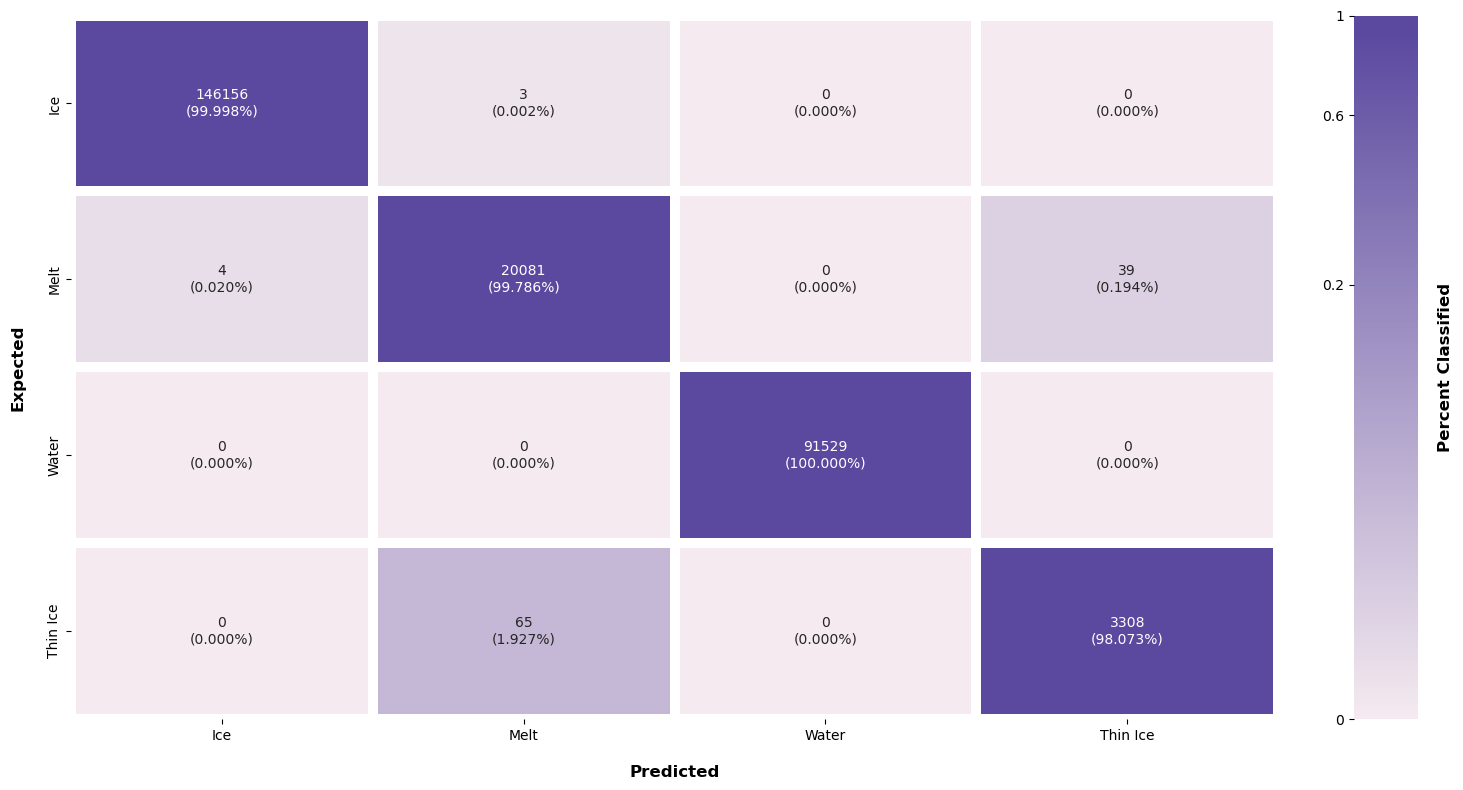

In [ ]:
# compute confusion matrix

labels = [1, 2, 3, 4]
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

# create annotation labels (count + percentage)

annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_norm[i, j]:.3%})"

# create figure
class_names = [
    "Ice",
    "Melt",
    "Water",
    "Thin Ice"
]

plt.figure(figsize=(16, 8))

ax = sns.heatmap(
    cm_norm,
    annot=annot,
    fmt="",
    cmap=custom_cmap,
    norm=PowerNorm(gamma=0.3),
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=6,
    linecolor=BG_COLOR,
    cbar_kws={
        "label": "Percent Classified",
        "aspect": 11,
        "ticks": [0, 0.2, 0.6, 1.0]
    }
)

# Added 'labelpad' to create that teensy bit of extra spacing
ax.set_xlabel("Predicted", fontsize=12, weight="bold", labelpad=16)
ax.set_ylabel("Expected", fontsize=12, weight="bold", labelpad=16)

plt.xticks(rotation=0)
plt.yticks(rotation=90)

# --- Colorbar Customization ---
cbar = ax.collections[0].colorbar

# 1. Update the label strings to match your specified ticks
cbar.set_ticklabels(['0', '0.2', '0.6', '1'])
cbar.ax.yaxis.set_ticks_position('left')

# Make the colorbar title bold and space it out a bit too
cbar.ax.set_ylabel("Percent Classified", fontsize=12, weight="bold", labelpad=15)

ax.set_facecolor(BG_COLOR)
plt.tight_layout()
plt.savefig('../../figures/MLfigures/confusionMatrix.png', dpi=300, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

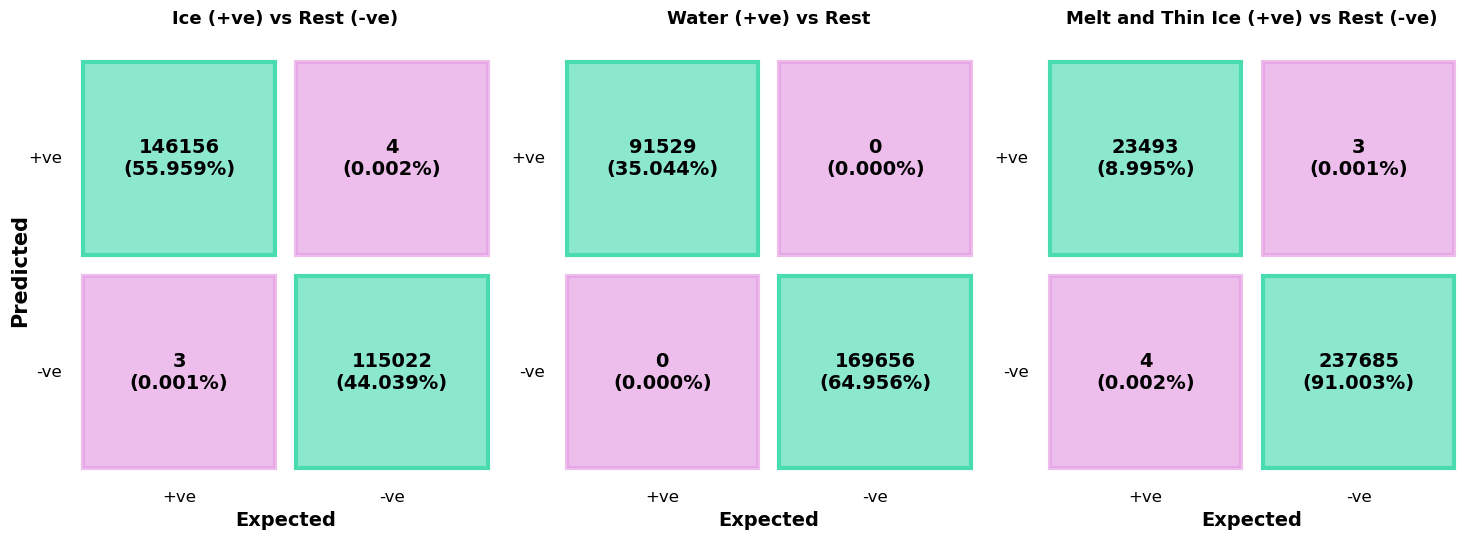

In [116]:
# define classes
groups = {
    "Ice (+ve) vs Rest (-ve)": [1],
    "Water (+ve) vs Rest": [3],
    "Melt and Thin Ice (+ve) vs Rest (-ve)": [2, 4]
}

# multiclass confusion matrix
# (Assuming 'data' is already defined in your environment)
y_true = data["class_id"]
y_pred = data["classification"]
labels = sorted(np.unique(np.concatenate((y_true, y_pred))))
cm = confusion_matrix(y_true, y_pred, labels=labels)

# collapse to binary (function)
def collapse_group(cm, positive_classes, labels):
    pos_idx = [labels.index(c) for c in positive_classes]

    # scikit-learn standard: rows = expected, cols = predicted
    TP = cm[np.ix_(pos_idx, pos_idx)].sum()
    
    # Expected positives (rows) that were predicted as something else
    FN = cm[pos_idx, :].sum() - TP
    
    # Expected negatives that were predicted as positive (cols)
    FP = cm[:, pos_idx].sum() - TP
    
    TN = cm.sum() - (TP + FP + FN)

    # Returning formatted for your custom graph: 
    # Row 0 = Predicted +ve (TP, FP)
    # Row 1 = Predicted -ve (FN, TN)
    return np.array([[TP, FP],
                     [FN, TN]])

# create fig
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.patch.set_facecolor("white")

for ax, (title, class_group) in zip(axes, groups.items()):
    binary_cm = collapse_group(cm, class_group, labels)

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor(BG_COLOR)
    
    # Remove default axes borders
    for spine in ax.spines.values():
        spine.set_visible(False)

    # draw squares manually
    colors = [
        ("#49DCB1a1", "#49DCB1"),  # TP
        ("#E499E1a1", "#E499E1a1"),  # FP
        ("#E499E1a1", "#E499E1a1"),  # FN
        ("#49DCB1a1", "#49DCB1")   # TN
    ]

    values = binary_cm.flatten()
    total = binary_cm.sum()
    
    # Calculate percentages (protecting against division by zero)
    percentages = (values / total * 100) if total > 0 else np.zeros_like(values)

    idx = 0
    pad = 0.05  # Spacing between squares

    for i in range(2):
        for j in range(2):
            fill_color, edge_color = colors[idx]

            rect = plt.Rectangle(
                (j + pad, i + pad),
                1 - 2 * pad, 
                1 - 2 * pad,
                facecolor=fill_color,
                edgecolor=edge_color,
                linewidth=3
            )
            ax.add_patch(rect)

            # Added the percentage variable to the text formatting
            ax.text(
                j + 0.5,
                i + 0.5,
                f"{values[idx]}\n({percentages[idx]:.3f}%)",
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold"
            )

            idx += 1

    ax.set_title(title, fontsize=13, fontweight="bold", pad=20)

    # Expected label and its +ve/-ve indicators
    ax.text(1, 2.15, "Expected", ha="center", va="top", fontsize=14, fontweight="bold")
    ax.text(0.5, 2.05, "+ve", ha="center", va="top", fontsize=12)
    ax.text(1.5, 2.05, "-ve", ha="center", va="top", fontsize=12)

    # Predicted +ve/-ve indicators
    ax.text(-0.05, 0.5, "+ve", va="center", ha="right", fontsize=12)
    ax.text(-0.05, 1.5, "-ve", va="center", ha="right", fontsize=12)

# Add a single master "Predicted" label for the entire figure
fig.supylabel("Predicted", fontsize=15, fontweight="bold")

plt.tight_layout()
plt.savefig('../../figures/MLfigures/binaryConfusionMatrix.png', dpi=300, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

In [117]:
# compute metrics for each class

classes = sorted(y_true.unique())
class_labels = ["Ice", "Melt", "Water", "Thin Ice"]

metrics = {
    "F1 Score":           f1_score(y_true, y_pred, average=None, labels=classes),
    "Precision":          precision_score(y_true, y_pred, average=None, labels=classes),
    "Recall":             recall_score(y_true, y_pred, average=None, labels=classes),
}

per_class_acc = []
for c in classes:
    mask = y_true == c
    per_class_acc.append((y_pred[mask] == y_true[mask]).mean())
metrics["Per-Class Accuracy"] = np.array(per_class_acc)

# build DataFrame (metrics as rows, classes as columns)

df_metrics = pd.DataFrame(metrics, index=class_labels).T

# append total column

df_metrics["Total"] = [
    f1_score(y_true, y_pred, average="macro"),
    precision_score(y_true, y_pred, average="macro"),
    recall_score(y_true, y_pred, average="macro"),
    accuracy_score(y_true, y_pred),
]

df_metrics = df_metrics.round(4)

# export to .tex in my thesis format

col_labels = list(df_metrics.columns)
n_cols = len(col_labels)
col_format = "@{\\extracolsep{\\fill}}l" + "r" * n_cols

header = " & ".join(col_labels) + " \\\\"

rows = []
for idx, row in df_metrics.iterrows():
    values = " & ".join(f"{v:.4f}" for v in row)
    rows.append(f"{idx} & {values} \\\\")

body = "\n".join(rows)

tex = f"""\\begin{{table}}
\\label{{tab:rf_classification_metrics}}
\\begin{{tabular*}}{{\\textwidth}}{{{col_format}}}
\\toprule
 & {header}
\\midrule
{body}
\\bottomrule
\\end{{tabular*}}
\\caption{{Per-class classification metrics for the Ocean Cover Random Forest classifier}}
\\end{{table}}"""

with open("../../figures/MLfigures/classification_metrics.tex", "w") as f:
    f.write(tex)

df_metrics

,Ice,Melt,Water,Thin Ice,Total
F1 Score,1.0,0.9972,1.0,0.9845,0.9954
Precision,1.0,0.9966,1.0,0.9883,0.9962
Recall,1.0,0.9979,1.0,0.9807,0.9946
Per-Class Accuracy,1.0,0.9979,1.0,0.9807,0.9996


**Training Data Spectra**

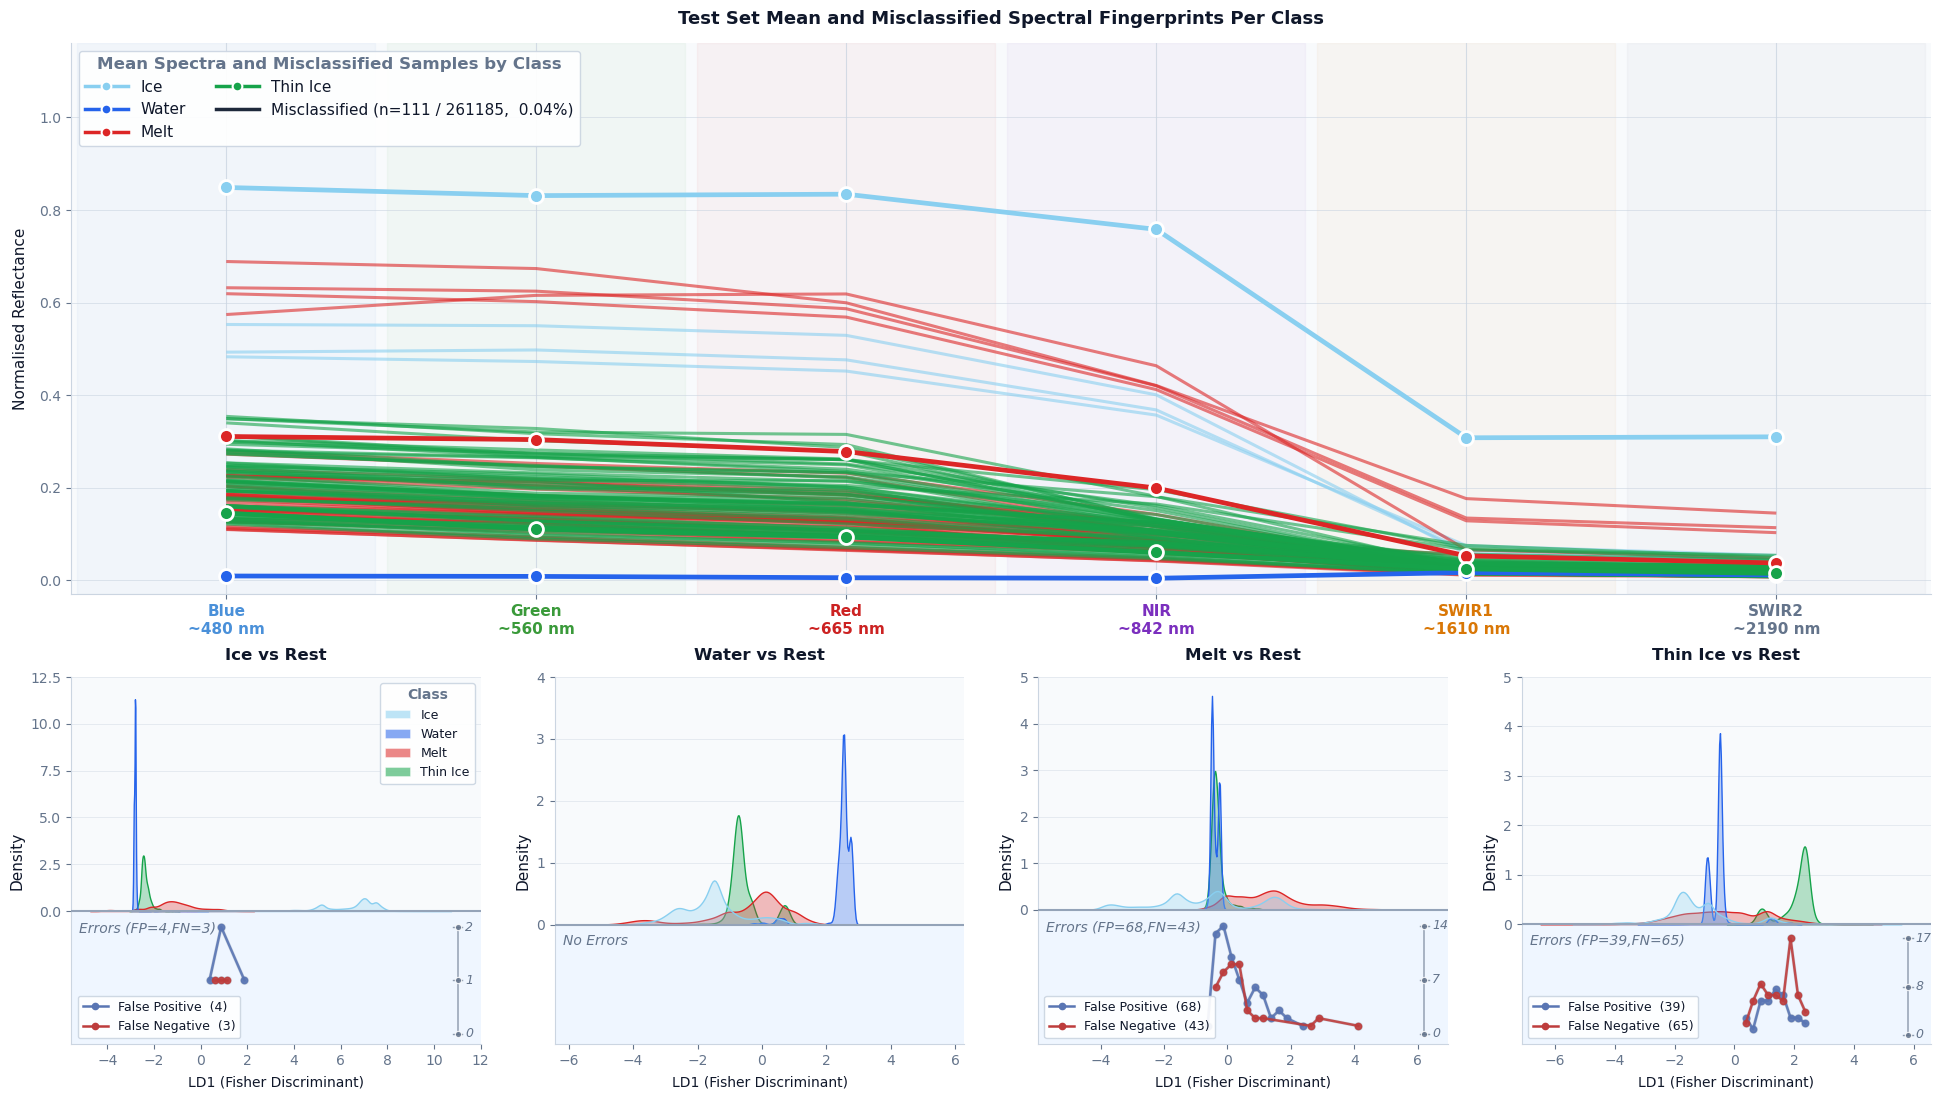

In [174]:
# palette and plotting parameters

FEATURE_COLS = ['blue', 'green', 'red', 'nir', 'swir1', 'swir2']
BAND_LABELS  = ['Blue\n~480 nm', 'Green\n~560 nm', 'Red\n~665 nm',
                'NIR\n~842 nm', 'SWIR1\n~1610 nm', 'SWIR2\n~2190 nm']
BAND_WL_COLORS = ['#4A90D9', '#3a9a3a', '#CC2222', '#7B2FBE', '#D97706', '#64748B']

class_names = {1: 'Ice', 2: 'Melt', 3: 'Water', 4: 'Thin Ice'}

class_palette = {
    'Ice':'#89CFF0',
    'Water':'#2563EB',
    'Melt':'#DC2626',
    'Thin Ice':'#16A34A',
}
class_palette_faint = {
    'Ice': '#D6EEF8',
    'Water':'#BFCFEE',
    'Melt':'#F2CCCC',
    'Thin Ice':'#C2DEC2',
}
class_order = ['Ice', 'Water', 'Melt', 'Thin Ice']

binary_groups = {
    "Ice vs Rest": ([1], "Ice"),
    "Water vs Rest": ([3], "Water"),
    "Melt vs Rest": ([2], "Melt"),
    "Thin Ice vs Rest": ([4], "Thin Ice"),
}

FP_COLOR = "#5975B3"
FN_COLOR = "#BD3C3C"

# light theme colors

LIGHT_BG = '#FFFFFF'
PANEL_BG = '#F8FAFC'
GRID_COLOR = '#CBD5E1'
TEXT_COLOR = '#0F172A'
SUBTEXT_COLOR = '#64748B'
SEPARATOR_COLOR = '#94A3B8'
BAND_BG_ALPHA = 0.04

BIN_WIDTH = 0.25
BAND_FRAC = 0.60
N_CORRECT = 0

# legend helpers

legend_kw = dict(
    fontsize=9, title_fontsize=10, framealpha=0.92,
    facecolor='white', edgecolor=GRID_COLOR,
    labelcolor=TEXT_COLOR,
)

def style_legend(leg):
    leg.get_title().set_color(SUBTEXT_COLOR)
    leg.get_title().set_fontweight('bold')

# PREPARE DATA

df_vis = data.copy()
df_vis['class_label'] = df_vis['class_id'].map(class_names)
df_vis['correct'] = (df_vis['class_id'] == df_vis['classification'])

X_raw  = df_vis[FEATURE_COLS].values.astype(float)
col_min, col_max = X_raw.min(0), X_raw.max(0)
X_norm = (X_raw - col_min) / (col_max - col_min + 1e-10)
norm_cols = [f'{c}_n' for c in FEATURE_COLS]
df_vis[norm_cols] = X_norm

n_bands = len(FEATURE_COLS)
x_pos = np.arange(n_bands, dtype=float)

# rcParams (light)

plt.rcParams.update({
    'text.color': TEXT_COLOR,
    'axes.labelcolor': TEXT_COLOR,
    'xtick.color': SUBTEXT_COLOR,
    'ytick.color': SUBTEXT_COLOR,
    'axes.edgecolor': GRID_COLOR,
})

# create base figure / axes

fig = plt.figure(figsize=(24, 13), facecolor=LIGHT_BG)
gs  = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1.5, 1], hspace=0.18)

ax_para = fig.add_subplot(gs[0])
gs_lda  = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs[1], wspace=0.18)
lda_axes = [fig.add_subplot(gs_lda[j]) for j in range(4)]

for ax in [ax_para] + lda_axes:
    ax.set_facecolor(PANEL_BG)
    for sp in ax.spines.values():
        sp.set_color(GRID_COLOR)

# PANEL ONE
# spectral signatures (with misclassified spectra highlighted)

def make_lc(X_vals, x_pos, color, alpha, lw, zorder=2):
    segs = [np.column_stack([x_pos, row]) for row in X_vals]
    return LineCollection(segs, color=color, alpha=alpha, linewidth=lw, zorder=zorder)

# wavelength band backgrounds

for j, bc in enumerate(BAND_WL_COLORS):
    ax_para.axvspan(j - 0.48, j + 0.48, alpha=BAND_BG_ALPHA, color=bc, zorder=0)

# vertical band separators

for j in x_pos:
    ax_para.axvline(j, color=GRID_COLOR, lw=0.8, alpha=0.8, zorder=1)

# paint individual spectra lines

for cls in class_order:
    mask = (df_vis['class_label'] == cls) & df_vis['correct']
    sub = df_vis[mask].sample(min(N_CORRECT, mask.sum()), random_state=42)
    if len(sub) == 0:
        continue
    ax_para.add_collection(
        make_lc(sub[norm_cols].values, x_pos,
                class_palette_faint[cls], 0.55, 0.4, zorder=2)
    )

# paint bold misclassified spectra lines

for cls in class_order:
    mask = (df_vis['class_label'] == cls) & (~df_vis['correct'])
    sub = df_vis[mask]
    if len(sub) == 0:
        continue
    Xe = sub[norm_cols].values
    ax_para.add_collection(make_lc(Xe, x_pos, class_palette[cls], 0.60, 2.2, zorder=4))

# paint bold mean lines with dots and shadow

for cls in class_order:
    mean = df_vis[df_vis['class_label'] == cls][norm_cols].mean().values
    col = class_palette[cls]

    # #shadow pass
    # ax_para.plot(x_pos, mean, color='#1E293B', lw=5.0, alpha=0.18, zorder=5,
    #              solid_capstyle='round')
    
    # main line w markers
    ax_para.plot(x_pos, mean, color=col, lw=3.4, alpha=1.0, zorder=6,
                 marker='o', ms=10, mec='white', mew=2.0,
                 solid_capstyle='round')

ax_para.set_xlim(-0.5, n_bands - 0.5)
ax_para.set_ylim(-0.03, 1.16)
ax_para.set_xticks(x_pos)
ax_para.set_xticklabels(BAND_LABELS, fontsize=11)
ax_para.set_ylabel('Normalised Reflectance', fontsize=11, labelpad=8)
ax_para.tick_params(axis='y', labelsize=10)
ax_para.spines['top'].set_visible(False)
ax_para.spines['right'].set_visible(False)
ax_para.yaxis.grid(True, color=GRID_COLOR, lw=0.6, alpha=0.7, zorder=0)
ax_para.set_axisbelow(True)

# title

ax_para.set_title(
    'Test Set Mean and Misclassified Spectral Fingerprints Per Class',
    weight='bold', fontsize=13, pad=14, color=TEXT_COLOR
)

# x-tick labels (wavelength colored)

for tick, col in zip(ax_para.get_xticklabels(), BAND_WL_COLORS):
    tick.set_color(col)
    tick.set_fontweight('bold')

# legend (style_legend(leg) heler at top of code block)

n_wrong = int((~df_vis['correct']).sum())
n_total = len(df_vis)
cls_handles = [
    Line2D([0],[0], color=class_palette[c], lw=2.5, marker='o',
           ms=7, mec='white', mew=1.5, label=c)
    for c in class_order
]

misc_handle = Line2D([0],[0], color='#1E293B', lw=2.5,
                     label=f'Misclassified (n={n_wrong} / {n_total},'
                           f'  {100*n_wrong/n_total:.2f}%)')
leg = ax_para.legend(
    handles=cls_handles + [misc_handle],
    title='Mean Spectra and Misclassified Samples by Class',
    loc='upper left', fontsize=11, title_fontsize=12,
    framealpha=0.92, frameon=True, ncol=2, handlelength=2.8,
    facecolor='white', edgecolor=GRID_COLOR, labelcolor=TEXT_COLOR,
)
style_legend(leg)

# PANELS 2-5
# LDA projections with KDEs, error bands, and error counts

kde_handles_lda = [
    mpatches.Patch(facecolor=class_palette[cls], alpha=0.55, label=cls,
                   edgecolor='white', linewidth=0.5)
    for cls in class_order
]

# define function to draw dot-line band for FP/FN distributions

def draw_dotline_band(ax, fp_vals, fn_vals, band_lo, band_h):
    all_vals = np.concatenate([fp_vals, fn_vals])
    if len(all_vals) == 0:
        return
    bin_edges   = np.arange(
        np.floor(all_vals.min() / BIN_WIDTH) * BIN_WIDTH,
        np.ceil(all_vals.max()  / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH,
        BIN_WIDTH
    )
    bin_centers = bin_edges[:-1] + BIN_WIDTH / 2
    global_max = max(
        np.histogram(fp_vals, bins=bin_edges)[0].max() if len(fp_vals) else 0,
        np.histogram(fn_vals, bins=bin_edges)[0].max() if len(fn_vals) else 0,
    )
    if global_max == 0:
        return
    pad_bot = band_lo + band_h * 0.08
    y_range = band_h * 0.80

    for vals, color in [(fp_vals, FP_COLOR), (fn_vals, FN_COLOR)]:
        if len(vals) == 0:
            continue
        counts = np.histogram(vals, bins=bin_edges)[0]
        mask = counts > 0
        if not mask.any():
            continue
        y_vals = pad_bot + (counts / global_max) * y_range
        ax.plot(bin_centers[mask], y_vals[mask], color='#1E293B',
                marker='o', ms=5.5, lw=2.5, alpha=0.12, zorder=4)
        ax.plot(bin_centers[mask], y_vals[mask], color=color,
                marker='o', ms=4.5, lw=1.8, alpha=0.90, zorder=5)

    # create mini scale axis on the far right of the band

    xlim = ax.get_xlim()
    ax_w = xlim[1] - xlim[0]
    x_axis = xlim[1] - ax_w * 0.03

    y_top = pad_bot + y_range
    y_mid = pad_bot + y_range * 0.5
    y_bot = pad_bot

    # vertical spine

    ax.plot([x_axis, x_axis], [y_bot, y_top],
            color=SUBTEXT_COLOR, lw=1.2, alpha=0.6, zorder=6,
            solid_capstyle='round')

    # three tick marks + dots

    tick_w = ax_w * 0.012
    for y_val, count_val in [
        (y_top, int(global_max)),
        (y_mid, int(global_max / 2)),
        (y_bot, 0),
    ]:
        # horizontal tick
        ax.plot([x_axis - tick_w, x_axis + tick_w], [y_val, y_val],
                color=SUBTEXT_COLOR, lw=1.0, alpha=0.7, zorder=7)
        
        # dot on the spine
        ax.plot(x_axis, y_val, 'o',
                color=SUBTEXT_COLOR, ms=4.5, alpha=0.85, zorder=8,
                mec='white', mew=0.8)
        
        # count label to the right
        ax.annotate(
            f'{count_val}',
            xy=(x_axis + tick_w * 1.6, y_val),
            fontsize=9, color=SUBTEXT_COLOR,
            ha='left', va='center', style='italic', zorder=9,
        )

# fit LDA, calculate LD1 projections, store FP/FN values for each binary group, and run KDE

lda_store = {}
lda_ymaxes = []

for i, (title, (pos_ids, _)) in enumerate(binary_groups.items()):
    df_train = training_data.copy()
    df_train['binary_label'] = np.where(df_train['class_id'].isin(pos_ids),
                                         'Positive', 'Negative')
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(df_train[FEATURE_COLS].values)
    lda = LinearDiscriminantAnalysis(n_components=1)
    lda.fit(Xtr, df_train['binary_label'].values)

    df_t = data.copy()
    df_t['class_label'] = df_t['class_id'].map(class_names)
    df_t['LD1'] = lda.transform(scaler.transform(df_t[FEATURE_COLS].values)).flatten()

    is_tp = df_t['class_id'].isin(pos_ids)
    is_pp = df_t['classification'].isin(pos_ids)
    fp_v = df_t[~is_tp & is_pp]['LD1'].values
    fn_v = df_t[is_tp  & ~is_pp]['LD1'].values

    ax = lda_axes[i]
    sns.kdeplot(data=df_t, x='LD1', hue='class_label',
                hue_order=class_order, palette=class_palette,
                fill=True, alpha=0.30, ax=ax, legend=False, common_norm=False)
    lda_ymaxes.append(ax.get_ylim()[1])
    lda_store[i] = dict(fp_vals=fp_v, fn_vals=fn_v, title=title)

# design KDE plots

for i, ax in enumerate(lda_axes):
    d = lda_store[i]
    fp_vals = d['fp_vals']
    fn_vals = d['fn_vals']
    band_h = lda_ymaxes[i] * BAND_FRAC
    band_lo = -band_h
    has_err = len(fp_vals) + len(fn_vals) > 0

    ax.set_ylim(band_lo, lda_ymaxes[i])
    ax.axhspan(band_lo, 0, color='#EFF6FF', alpha=1.0, zorder=0)
    ax.axhline(0, color=SEPARATOR_COLOR, lw=1.5, zorder=3)
    ax.yaxis.grid(True, color=GRID_COLOR, lw=0.5, alpha=0.6, zorder=0)
    ax.set_axisbelow(True)

    draw_dotline_band(ax, fp_vals, fn_vals, band_lo, band_h)

    # write "Error" or "No Errors" label in

    xlim = ax.get_xlim()
    ax.text(xlim[0] + 0.02*(xlim[1]-xlim[0]), -band_h * 0.08,
            f'Errors (FP={len(fp_vals)},FN={len(fn_vals)})'
            if has_err else 'No Errors',
            fontsize=10, color=SUBTEXT_COLOR,
            va='top', ha='left', style='italic')
    
    # titles and labels

    ax.set_title(d['title'], weight='bold', pad=12, fontsize=12, color=TEXT_COLOR)
    ax.set_xlabel('LD1 (Fisher Discriminant)', fontsize=10, labelpad=5)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_yticks([t for t in ax.get_yticks() if t >= 0])
    ax.tick_params(labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fph = Line2D([0],[0], color=FP_COLOR, marker='o', linestyle='-',
                 ms=4.5, lw=1.8, label=f'False Positive  ({len(fp_vals)})')
    fnh = Line2D([0],[0], color=FN_COLOR, marker='o', linestyle='-',
                 ms=4.5, lw=1.8, label=f'False Negative  ({len(fn_vals)})')

    if i == 0:
        kl = ax.legend(handles=kde_handles_lda, title='Class',
                       loc='upper right', **legend_kw)
        style_legend(kl)
        ax.add_artist(kl)
        el = ax.legend(handles=[fph, fnh], title='',
                       loc='lower left', **legend_kw)
        style_legend(el)
    elif has_err:
        el = ax.legend(handles=[fph, fnh], title='',
                       loc='lower left', **legend_kw)
        style_legend(el)

# save and show

plt.savefig('../../figures/MLfigures/spectral_grand_unified_light.png',
            dpi=300, bbox_inches='tight', facecolor=LIGHT_BG)
plt.show()
plt.rcParams.update(plt.rcParamsDefault)

**Counts and Tables**

In [119]:
# S2

iceS2 = len(data.loc[data['class_id'] == 1].loc[data['sensor'] == 1])
waterS2 = len(data.loc[data['class_id'] == 3].loc[data['sensor'] == 1])
meltS2 = len(data.loc[data['class_id'] == 2].loc[data['sensor'] == 1])
thinIceS2 = len(data.loc[data['class_id'] == 4].loc[data['sensor'] == 1])

# L8/9

iceL89 = len(data.loc[data['class_id'] == 1].loc[data['sensor'] == 0])
waterL89 = len(data.loc[data['class_id'] == 3].loc[data['sensor'] == 0])
meltL89 = len(data.loc[data['class_id'] == 2].loc[data['sensor'] == 0])
thinIceL89 = len(data.loc[data['class_id'] == 4].loc[data['sensor'] == 0])

# totals

iceTot = iceS2 + iceL89
waterTot = waterS2 + waterL89
meltTot = meltS2 + meltL89
thinIceTot = thinIceS2 + thinIceL89


lists = [
    [iceL89, iceS2, iceTot],
    [waterL89, waterS2, waterTot],
    [meltL89, meltS2, meltTot],
    [thinIceL89, thinIceS2, thinIceTot]
]


columns = ["Landsat 8/9", "Sentinel 2", "Total"]
index = ['Ice', 'Melt', 'Water', 'Thin Ice']

df = pd.DataFrame(lists, columns=columns, index=index)
df['Proportion'] = df['Total'] / df['Total'].sum() * 100
df['Proportion'] = df['Proportion'].apply(lambda x: f"{x:.1f}\\%")

latex_str = df.to_latex(
    float_format="%.1f",
    caption="Testing sample counts by class and sensor",
    label="tab:training_samples",
    column_format="lrrrr"
)

with open('../../figures/MLfigures/testing_sample_table.tex', 'w') as f:
    f.write(latex_str)

df

,Landsat 8/9,Sentinel 2,Total,Proportion
Ice,77900,68259,146159,56.0\%
Melt,69134,22395,91529,35.0\%
Water,12799,7325,20124,7.7\%
Thin Ice,2776,597,3373,1.3\%


In [120]:
data_full = pd.read_csv('../../local_data/RFTrainingAsset.csv')

# S2

iceS2 = len(data_full.loc[data_full['class_id'] == 1].loc[data_full['sensor'] == 1])
waterS2 = len(data_full.loc[data_full['class_id'] == 3].loc[data_full['sensor'] == 1])
meltS2 = len(data_full.loc[data_full['class_id'] == 2].loc[data_full['sensor'] == 1])
thinIceS2 = len(data_full.loc[data_full['class_id'] == 4].loc[data_full['sensor'] == 1])

# L8/9

iceL89 = len(data_full.loc[data_full['class_id'] == 1].loc[data_full['sensor'] == 0])
waterL89 = len(data_full.loc[data_full['class_id'] == 3].loc[data_full['sensor'] == 0])
meltL89 = len(data_full.loc[data_full['class_id'] == 2].loc[data_full['sensor'] == 0])
thinIceL89 = len(data_full.loc[data_full['class_id'] == 4].loc[data_full['sensor'] == 0])

# totals

iceTot = iceS2 + iceL89
waterTot = waterS2 + waterL89
meltTot = meltS2 + meltL89
thinIceTot = thinIceS2 + thinIceL89


lists = [
    [iceL89, iceS2, iceTot],
    [waterL89, waterS2, waterTot],
    [meltL89, meltS2, meltTot],
    [thinIceL89, thinIceS2, thinIceTot]
]


columns = ["Landsat 8/9", "Sentinel 2", "Total"]
index = ['Ice', 'Melt', 'Water', 'Thin Ice']

df = pd.DataFrame(lists, columns=columns, index=index)
df['Proportion'] = df['Total'] / df['Total'].sum() * 100
df['Proportion'] = df['Proportion'].apply(lambda x: f"{x:.1f}\\%")

latex_str = df.to_latex(
    float_format="%.1f",
    caption="Training sample counts by class and sensor",
    label="tab:training_samples",
    column_format="lrrrr"
)

with open('../../figures/MLfigures/training_sample_table.tex', 'w') as f:
    f.write(latex_str)

df

,Landsat 8/9,Sentinel 2,Total,Proportion
Ice,390643,339743,730386,56.1\%
Melt,344437,112100,456537,35.0\%
Water,62557,36458,99015,7.6\%
Thin Ice,13655,2984,16639,1.3\%


Training Data Locations

In [121]:
# define coordinates for every training image

coordsL8 = [
{'row': 68, 'col': 318},
{'row': 196, 'col': 195},
{'row': 140, 'col': 163},
{'row': 124, 'col': 253},
{'row': 123, 'col': 285},
{'row': 73, 'col': 214},
{'row': 178, 'col': 268},
{'row': 246, 'col': 222},
{'row': 251, 'col': 321},
{'row': 88, 'col': 258},
{'row': 73, 'col': 160},
{'row': 116, 'col': 270}]
coordsL9 = [
{'row': 82, 'col': 206},
{'row': 201, 'col': 193},
{'row': 75, 'col': 187},
{'row': 126, 'col': 324},
{'row': 100, 'col': 116},
{'row': 120, 'col': 304}]
coordsS2 = [
{'row': 100, 'col': 240},
{'row': 107, 'col': 166},
{'row': 208, 'col': 324},
{'row': 147, 'col': 181},
{'row': 81, 'col': 241},
{'row': 69, 'col': 259},
{'row': 203, 'col': 199},
{'row': 86, 'col': 240},
{'row': 200, 'col': 221},
{'row': 132, 'col': 302},
{'row': 122, 'col': 321},
{'row': 76, 'col': 176}]

In [122]:
# read in the coordinate to lat/lon mapping file

coord_mapping = pd.read_csv('../../local_data/CoastCellInfoJan5_10.csv')
coord_mapping.head()

,Row,Col,Edge 1/0,Lat1,Lat2,Lat3,Lat4,Lon1,Lon2,Lon3,Lon4
0,23,216,0,60.150632,60.364729,60.393578,60.179238,-142.823711,-142.883139,-142.450249,-142.394009
1,23,217,0,60.179238,60.393578,60.420809,60.206238,-142.394009,-142.450249,-142.016502,-141.963469
2,23,218,0,60.206238,60.420809,60.446416,60.231628,-141.963469,-142.016502,-141.581945,-141.532137
3,23,219,0,60.231628,60.446416,60.470395,60.255403,-141.532137,-141.581945,-141.146626,-141.100060
4,24,210,1,60.157985,60.370496,60.409253,60.196416,-145.459909,-145.539184,-145.109298,-145.033121


Saved to ../../figures/MLfigures/training_data_map.png


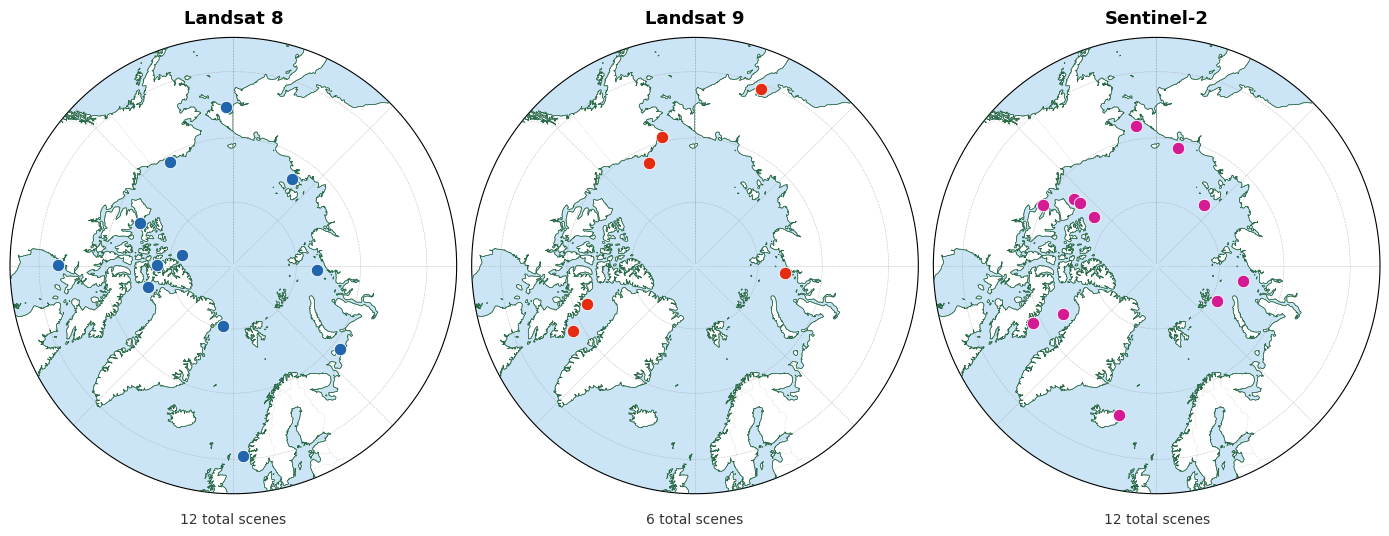

In [131]:
# read in the coordinate to lat/lon mapping file

coord_mapping = pd.read_csv('../../local_data/CoastCellInfoJan5_10.csv')
coord_mapping.columns = coord_mapping.columns.str.strip()

# training image coordinates

coordsL8 = [
{'row': 68, 'col': 318}, {'row': 196, 'col': 195},
{'row': 140, 'col': 163}, {'row': 124, 'col': 253},
{'row': 123, 'col': 285}, {'row': 73, 'col': 214},
{'row': 178, 'col': 268}, {'row': 246, 'col': 222},
{'row': 251, 'col': 321}, {'row': 88, 'col': 258},
{'row': 73, 'col': 160}, {'row': 116, 'col': 270}]

coordsL9 = [
{'row': 82, 'col': 206}, {'row': 201, 'col': 193},
{'row': 75, 'col': 187}, {'row': 126, 'col': 324},
{'row': 100, 'col': 116}, {'row': 120, 'col': 304}]

coordsS2 = [
{'row': 100, 'col': 240}, {'row': 107, 'col': 166},
{'row': 208, 'col': 324}, {'row': 147, 'col': 181},
{'row': 81, 'col': 241}, {'row': 69, 'col': 259},
{'row': 203, 'col': 199}, {'row': 86, 'col': 240},
{'row': 200, 'col': 221}, {'row': 132, 'col': 302},
{'row': 122, 'col': 321}, {'row': 76, 'col': 176}]

# funtion to convert row/col to lat/lon

def coords_to_latlon(coord_list, mapping):
    lats, lons = [], []
    for c in coord_list:
        row = mapping[(mapping['Row'] == c['row']) & (mapping['Col'] == c['col'])]
        if len(row) == 0:
            print(f"  Warning: row={c['row']}, col={c['col']} not found in mapping")
            continue
        lat = row[['Lat1','Lat2','Lat3','Lat4']].values.mean()
        lon = row[['Lon1','Lon2','Lon3','Lon4']].values.mean()
        lats.append(lat)
        lons.append(lon)
    return np.array(lats), np.array(lons)

latsL8, lonsL8 = coords_to_latlon(coordsL8, coord_mapping)
latsL9, lonsL9 = coords_to_latlon(coordsL9, coord_mapping)
latsS2, lonsS2 = coords_to_latlon(coordsS2, coord_mapping)

# plotting

sensors = [
    ('Landsat 8',   latsL8, lonsL8, '#2166ac'),
    ('Landsat 9',   latsL9, lonsL9, "#e62c10"),
    ('Sentinel-2',  latsS2, lonsS2, "#d51b94"),
]

projection  = ccrs.NorthPolarStereo(central_longitude=0)
data_crs    = ccrs.PlateCarree()

fig, axes = plt.subplots(
    1, 3,
    figsize=(14, 5.5),
    subplot_kw={'projection': projection}
)

fig.patch.set_facecolor('white')

def make_circular_boundary(ax, lat_min=50):
    theta = np.linspace(0, 2 * np.pi, 200)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.set_extent([-180, 180, lat_min, 90], crs=data_crs)

for ax, (label, lats, lons, color) in zip(axes, sensors):

    make_circular_boundary(ax, lat_min=55)

    # background and features

    ax.set_facecolor('#cce5f6')
    ax.add_feature(cfeature.LAND,
                   facecolor="#ffffff",
                   edgecolor="#487960",
                   linewidth=0.4,
                   zorder=2)
    ax.add_feature(cfeature.COASTLINE,
                   edgecolor="#256844",
                   linewidth=0.5,
                   zorder=3)
    ax.add_feature(cfeature.BORDERS,
                   edgecolor='#aaaaaa',
                   linewidth=0.3,
                   linestyle=':',
                   zorder=3)

    # latitudes and gridlines

    gl = ax.gridlines(
        crs=data_crs,
        draw_labels=False,
        linewidth=0.4,
        color='#999999',
        alpha=0.6,
        linestyle='--',
        zorder=4
    )
    gl.ylocator = plt.FixedLocator([60, 70, 80])
    gl.xlocator = plt.FixedLocator(np.arange(-180, 181, 45))

    # scatter points

    ax.scatter(
        lons, lats,
        transform=data_crs,
        s=80,
        color=color,
        edgecolors='white',
        linewidths=0.6,
        zorder=5,
        label=label
    )

    # title

    ax.set_title(label, fontsize=13, fontweight='bold', pad=10)

    # num scenes text
    
    ax.text(
        0.5, -0.04,
        f'{len(lats)} total scenes',
        transform=ax.transAxes,
        ha='center', va='top',
        fontsize=10, color='#333333'
    )

# save figure

plt.tight_layout()
outpath = '../../figures/MLfigures/training_data_map.png'
plt.savefig(outpath, dpi=300, bbox_inches='tight', facecolor='white')
print(f'Saved to {outpath}')
plt.show()

/var/folders/2h/wmx3j_b939s4yycx33j18njr0000gn/T/ipykernel_29951/1363872799.py:177: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


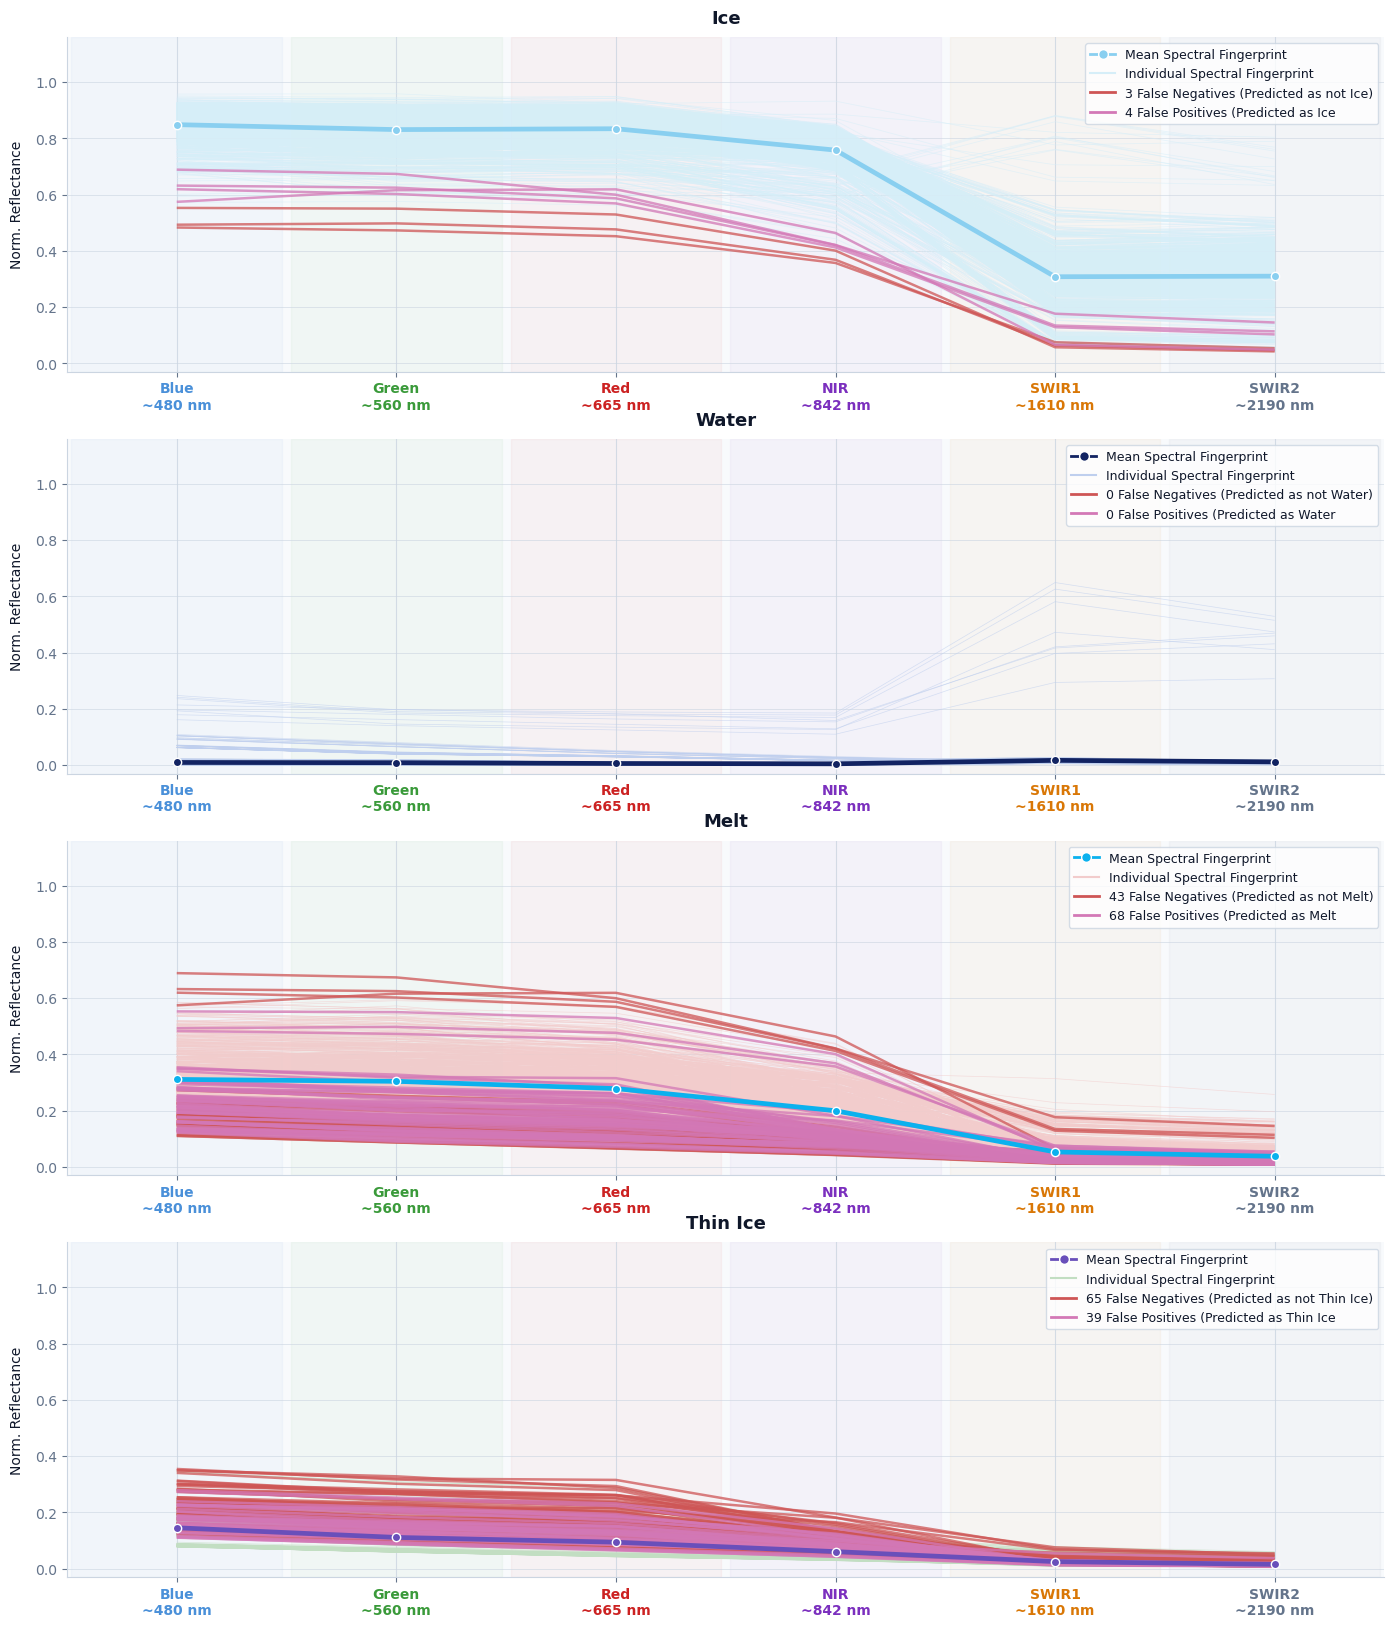

In [15]:
# palette and plotting parameters

FEATURE_COLS = ['blue', 'green', 'red', 'nir', 'swir1', 'swir2']
BAND_LABELS  = ['Blue\n~480 nm', 'Green\n~560 nm', 'Red\n~665 nm',
                'NIR\n~842 nm', 'SWIR1\n~1610 nm', 'SWIR2\n~2190 nm']
BAND_WL_COLORS = ['#4A90D9', '#3a9a3a', '#CC2222', '#7B2FBE', '#D97706', '#64748B']

class_names = {1: 'Ice', 2: 'Melt', 3: 'Water', 4: 'Thin Ice'}

class_palette = {
    'Ice':      '#89CFF0',
    'Water':    "#122362",
    'Melt':     "#0BB1EE",
    'Thin Ice': "#694FBA",
}
class_palette_faint = {
    'Ice':      '#D6EEF8',
    'Water':    '#BFCFEE',
    'Melt':     '#F2CCCC',
    'Thin Ice': '#C2DEC2',
}
class_order = ['Ice', 'Water', 'Melt', 'Thin Ice']

class_ids = {v: k for k, v in class_names.items()}

FP_COLOR = "#D378B6"
FN_COLOR = "#CE5555"

LIGHT_BG       = '#FFFFFF'
PANEL_BG       = '#F8FAFC'
GRID_COLOR     = '#CBD5E1'
TEXT_COLOR     = '#0F172A'
SUBTEXT_COLOR  = '#64748B'
BAND_BG_ALPHA  = 0.04

N_CORRECT = 1000

legend_kw = dict(
    fontsize=9, title_fontsize=10, framealpha=0.92,
    facecolor='white', edgecolor=GRID_COLOR,
    labelcolor=TEXT_COLOR,
)

def style_legend(leg):
    leg.get_title().set_color(SUBTEXT_COLOR)
    leg.get_title().set_fontweight('bold')

# ── PREPARE DATA ──────────────────────────────────────────────────────────────

df_vis = data.copy()
df_vis['class_label'] = df_vis['class_id'].map(class_names)
df_vis['correct']     = (df_vis['class_id'] == df_vis['classification'])

X_raw  = df_vis[FEATURE_COLS].values.astype(float)
col_min, col_max = X_raw.min(0), X_raw.max(0)
X_norm = (X_raw - col_min) / (col_max - col_min + 1e-10)
norm_cols = [f'{c}_n' for c in FEATURE_COLS]
df_vis[norm_cols] = X_norm

n_bands = len(FEATURE_COLS)
x_pos   = np.arange(n_bands, dtype=float)

plt.rcParams.update({
    'text.color':       TEXT_COLOR,
    'axes.labelcolor':  TEXT_COLOR,
    'xtick.color':      SUBTEXT_COLOR,
    'ytick.color':      SUBTEXT_COLOR,
    'axes.edgecolor':   GRID_COLOR,
})

# ── HELPERS ───────────────────────────────────────────────────────────────────

def make_lc(X_vals, x_pos, color, alpha, lw, zorder=2):
    segs = [np.column_stack([x_pos, row]) for row in X_vals]
    return LineCollection(segs, color=color, alpha=alpha, linewidth=lw, zorder=zorder)

# ── FIGURE ────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(8.5*2, 10*2), facecolor=LIGHT_BG)
gs  = gridspec.GridSpec(4, 1, figure=fig, hspace=0.2)

for row_idx, cls in enumerate(class_order):
    ax = fig.add_subplot(gs[row_idx])
    ax.set_facecolor(PANEL_BG)
    for sp in ax.spines.values():
        sp.set_color(GRID_COLOR)

    cls_id    = class_ids[cls]
    cls_color = class_palette[cls]
    cls_faint = class_palette_faint[cls]

    # ── wavelength band backgrounds ──────────────────────────────────────────
    for j, bc in enumerate(BAND_WL_COLORS):
        ax.axvspan(j - 0.48, j + 0.48, alpha=BAND_BG_ALPHA, color=bc, zorder=0)

    # ── vertical band separators ─────────────────────────────────────────────
    for j in x_pos:
        ax.axvline(j, color=GRID_COLOR, lw=0.8, alpha=0.8, zorder=1)

    # ── individual correct spectra (up to N_CORRECT) ─────────────────────────
    correct_mask = (df_vis['class_label'] == cls) & df_vis['correct']
    sub_correct  = df_vis[correct_mask].sample(
        min(N_CORRECT, correct_mask.sum()), random_state=42
    )
    if len(sub_correct):
        ax.add_collection(
            make_lc(sub_correct[norm_cols].values, x_pos,
                    cls_faint, 0.60, 0.5, zorder=2)
        )

    # ── false negatives: solid FN line ────────────────────────────────────────
    fn_mask = (df_vis['class_label'] == cls) & (~df_vis['correct'])
    sub_fn  = df_vis[fn_mask]
    if len(sub_fn):
        ax.add_collection(
            make_lc(sub_fn[norm_cols].values, x_pos,
                    FN_COLOR, 0.75, 1.8, zorder=4)
        )

    # ── false positives: solid FP line ───────────────────────────────────────
    fp_mask = (df_vis['class_label'] != cls) & (df_vis['classification'] == cls_id)
    sub_fp  = df_vis[fp_mask]
    if len(sub_fp):
        ax.add_collection(
            make_lc(sub_fp[norm_cols].values, x_pos,
                    FP_COLOR, 0.75, 1.8, zorder=4)
        )

    # ── bold mean line ────────────────────────────────────────────────────────
    mean_vals = df_vis[df_vis['class_label'] == cls][norm_cols].mean().values
    ax.plot(x_pos, mean_vals, color=cls_color, lw=3.4, alpha=1.0, zorder=6,
            marker='o', ms=6, mec='white', mew=1,
            solid_capstyle='round')

    # ── axes formatting ───────────────────────────────────────────────────────
    ax.set_xlim(-0.5, n_bands - 0.5)
    ax.set_ylim(-0.03, 1.16)
    ax.set_xticks(x_pos)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, color=GRID_COLOR, lw=0.6, alpha=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.set_ylabel('Norm. Reflectance', fontsize=10, labelpad=8)

    # ── band labels on every panel, wavelength-coloured ───────────────────────
    ax.set_xticklabels(BAND_LABELS, fontsize=10)
    for tick, col in zip(ax.get_xticklabels(), BAND_WL_COLORS):
        tick.set_color(col)
        tick.set_fontweight('bold')

    # ── centred black title ───────────────────────────────────────────────────
    ax.set_title(cls, weight='bold', fontsize=13, pad=10,
                 color=TEXT_COLOR, loc='center')

    # ── per-panel legend ──────────────────────────────────────────────────────
    n_fn  = len(sub_fn)
    n_fp  = len(sub_fp)

    handles = [
        Line2D([0], [0], color=cls_color, lw=2, marker='o', ms=7,
               mec='white', mew=1,
               label=f'Mean Spectral Fingerprint'),
        Line2D([0], [0], color=cls_faint, lw=1.5,
               label=f'Individual Spectral Fingerprint'),
        Line2D([0], [0], color=FN_COLOR, lw=2.0,
               label=f'{n_fn} False Negatives (Predicted as not {cls})'),
        Line2D([0], [0], color=FP_COLOR, lw=2.0,
               label=f'{n_fp} False Positives (Predicted as {cls}'),
    ]
    leg = ax.legend(handles=handles, loc='upper right',
                    fontsize=9, title_fontsize=10,
                    framealpha=0.8, frameon=True,
                    facecolor='white', edgecolor=GRID_COLOR,
                    labelcolor=TEXT_COLOR)
    style_legend(leg)

plt.tight_layout()
plt.savefig('../../figures/MLfigures/spectral_bands.png',
            dpi=300, bbox_inches='tight', facecolor=LIGHT_BG)
plt.show()
plt.rcParams.update(plt.rcParamsDefault)